In [1]:
from eval.recallevalv2 import Evaluation

evaluator = Evaluation(modelname='mammoclip')
dfr = evaluator.run_eval()


/home/ixb004/miniconda3/envs/mammoalbef/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.4 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


Loading saved results from: /mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/embeddings/mammoclip-test-recall@1_5_10-ml256.csv
----Saving results to /mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/embeddings/mammoclip-test-final-recall.csv----
          Metric mammoclip Rare (n=12330) mammoclip Freq (n=59998)  \
0   I2T Recall@1  0.0109 [0.0090, 0.0127]  0.0491 [0.0474, 0.0508]   
1   I2T Recall@5  0.0314 [0.0283, 0.0345]  0.1270 [0.1243, 0.1297]   
2  I2T Recall@10  0.0474 [0.0437, 0.0512]  0.1600 [0.1570, 0.1629]   
3   T2I Recall@1  0.0077 [0.0062, 0.0092]  0.0346 [0.0331, 0.0360]   
4   T2I Recall@5  0.0377 [0.0343, 0.0411]  0.6043 [0.6004, 0.6082]   
5  T2I Recall@10  0.0956 [0.0904, 0.1008]  0.7789 [0.7756, 0.7822]   

   mammoclip All (n=72328)  
0  0.0426 [0.0411, 0.0441]  
1  0.1107 [0.1084, 0.1130]  
2  0.1408 [0.1383, 0.1433]  
3  0.0300 [0.0287, 0.0312]  
4  0.5077 [0.5041, 0.5114]  
5  0.6624 [0.6590, 0.6658]  


,Metric,mammoclip Rare (n=12330),mammoclip Freq (n=59998),mammoclip All (n=72328)
0,I2T Recall@1,"0.0109 [0.0090, 0.0127]","0.0491 [0.0474, 0.0508]","0.0426 [0.0411, 0.0441]"
1,I2T Recall@5,"0.0314 [0.0283, 0.0345]","0.1270 [0.1243, 0.1297]","0.1107 [0.1084, 0.1130]"
2,I2T Recall@10,"0.0474 [0.0437, 0.0512]","0.1600 [0.1570, 0.1629]","0.1408 [0.1383, 0.1433]"
3,T2I Recall@1,"0.0077 [0.0062, 0.0092]","0.0346 [0.0331, 0.0360]","0.0300 [0.0287, 0.0312]"
4,T2I Recall@5,"0.0377 [0.0343, 0.0411]","0.6043 [0.6004, 0.6082]","0.5077 [0.5041, 0.5114]"
5,T2I Recall@10,"0.0956 [0.0904, 0.1008]","0.7789 [0.7756, 0.7822]","0.6624 [0.6590, 0.6658]"


In [1]:
from model_utils import load_model, build_multiview_model
from multiview_model import BreastClipMIRAITransformer
from datasets.data_utils import load_dataloader
# from datasets.uw_dataset import ft_uw_individual, ft_train_dataset_group
import sys
sys.path.append('..')
from breastclip.model import build_model
from breastclip.model.modules import load_image_encoder, LinearClassifier, load_text_encoder, load_projection_head
from breastclip.data.data_utils import load_tokenizer
from Classifiers.models.breast_clip_classifier import BreastClipClassifier
import torch
import os
from ruamel.yaml import YAML
import yaml
import pandas as pd
from types import SimpleNamespace
import json
import pandas as pd
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from accelerate import init_empty_weights
from mv_models import VisionLinearProbe
sys.path.insert(0,'/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/')
from dataset.utils import pre_caption, scale_0_1

# Define the args object with all required attributes
args = SimpleNamespace(
    hidden_dim=512,  # Hidden dimension for the transformer
    num_layers=3,    # Number of transformer layers
    num_heads=8,     # Number of attention heads
    num_images=2,    # Number of images (fixed to 4 as per your code)
    num_classes=2,   # Number of output classes (e.g., binary classification)
    dropout=0.25,    # Dropout rate
    # precomputed_hidden_dim=2048,  # Output dimension of the image encoder (e.g., ResNet50)
    device = 'cuda' if torch.cuda.is_available() else 'cpu',
    clip_chk_pt_path = '/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/checkpoints/b5-model-best-epoch-7.tar'
)

# Print the args object to verify
print(args)

/home/ixb004/miniconda3/envs/mammoalbef/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:numexpr.utils:Note: detected 256 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
INFO:numexpr.utils:Note: NumExpr detected 256 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.
INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.5 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


namespace(hidden_dim=512, num_layers=3, num_heads=8, num_images=2, num_classes=2, dropout=0.25, device='cpu', clip_chk_pt_path='/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/checkpoints/b5-model-best-epoch-7.tar')


/home/ixb004/miniconda3/envs/mammoalbef/lib/python3.9/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 802: system not yet initialized (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [25]:
df = pd.read_csv('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_pretrain_individual_lateralityv2.csv')

df = df[~df['birads'].isin([3, 6])]
df = df.sample(frac=0.009, random_state=42)
print(df.groupby('split')['birads'].value_counts())

# df['birads'] = df['birads'].apply(lambda x: 1 if x == 0 else 0)
# print(df.groupby('split')['birads'].value_counts())


split  birads
test   2           5
       1           2
       0           1
train  1         342
       2         236
       0          55
val    1           8
       0           1
       2           1
Name: count, dtype: int64


In [ ]:
def undersample(df , classname, split='train', random_state=42):
    """
    Undersample majority classes for the specified column to the count of the minority class.
    
    This method adjusts only the rows in self.ann with the given split.
    
    Args:
        classname (str): The column name on which to perform undersampling.
        split (str): The split to apply undersampling (default 'train').
        random_state (int): Seed for random sampling for reproducibility.
    """
    # Create a mask for the specified split.
    split_mask = df['split'] == split
    # Compute class distribution for the target column.
    class_counts = df.loc[split_mask, classname].value_counts()
    print("Distribution before balancing:", class_counts)
    
    # Determine the minimum class count.
    min_class_count = class_counts.min()
    
    # Collect indices of samples to drop for each class that exceeds the minimum count.
    drop_indices = []
    for class_label, count in class_counts.items():
        if count > min_class_count:
            n_to_drop = count - min_class_count
            # Sample n_to_drop indices from the current class.
            indices = df.loc[split_mask & (df[classname] == class_label)] \
                              .sample(n=n_to_drop, random_state=random_state).index
            drop_indices.extend(indices)
    
    # Drop the selected indices from df.
    df = df.drop(drop_indices)
    print("Distribution after undersampling:", 
          df.loc[df['split'] == split, classname].value_counts())
    return df

df = undersample(df, 'birads', split='train', random_state=42)

In [26]:
def undersample(df, column, split='train'):
    """Undersamples the majority class(es) in the specified column."""
    class_counts = df[df['split'] == split][column].value_counts()
    min_class_count = class_counts.min()
    
    undersampled_df = pd.concat([
        df[(df['split'] == split) & (df[column] == class_label)].sample(min_class_count, random_state=42)
        for class_label in class_counts.index
    ])
    print("Distribution after undersampling:", 
    undersampled_df[column].value_counts())
    return pd.concat([df[df['split'] != split], undersampled_df])
df = undersample(df, 'birads', 'train')

Distribution after undersampling: birads
1    55
2    55
0    55
Name: count, dtype: int64


In [18]:
def undersample(df, column, split='train'):
    """Undersamples the majority class(es) in the specified column."""
    class_counts = df[df['split'] == split][column].value_counts()
    print("Distribution before balancing:", class_counts)
    min_class_count = class_counts.min()
    print("min class count", min_class_count)
    undersampled_df = pd.concat([
        df[(df['split'] == split) & (df[column] == class_label)].sample(min_class_count, random_state=42)
        for class_label in class_counts.index
    ])
    print("Distribution after undersampling:", 
        df.loc[df['split'] == split, column].value_counts())
    return pd.concat([df[df['split'] != split], undersampled_df])

In [22]:
print(df.groupby('split')['birads'].value_counts())

split  birads
test   2          5
       1          2
       0          1
train  0         55
       1         55
       2         55
val    1          8
       0          1
       2          1
Name: count, dtype: int64


In [36]:
df = pd.read_csv('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_pretrain_individual_lateralityv2.csv')
print(df.groupby('split')['density'].value_counts())
df = df[~df['birads'].isin([3, 6])]
df['birads'] = df['birads'].apply(lambda x: 1 if x == 0 else 0)
classname = 'birads'
if classname == 'birads':
    # Birads Preprocess: drop 3 and 6, merge 1 and 2 -> 0 and 0 -> 1 for Binary Classification
    df = df[~df['birads'].isin([3, 6])]
    df['birads'] = df['birads'].apply(lambda x: 1 if x == 0 else 0)
    # Count the number of samples in each class
    class_0_count = df.loc[(df['split'] == 'train') & (df['birads'] == 0)].shape[0]
    class_1_count = df.loc[(df['split'] == 'train') & (df['birads'] == 1)].shape[0]
    # Undersample class 0 to match the number of samples in class 1
    if class_0_count > class_1_count:
        print('Undersampling class 0')
        class_0_indices = df.loc[(df['split'] == 'train') & (df['birads'] == 0)].sample(class_0_count - class_1_count, random_state=42).index
        df = df.drop(class_0_indices)
else:
    # Density Preprocess: drop -1
    df = df[~df['density'].isin([-1])]
    df['density'] = df['density'].astype(int)
    # Undersample majority classes to minority class
    class_counts = df.loc[df['split'] == 'train'].density.value_counts()
    min_class_count = min(class_counts)
    for class_label,count in class_counts.items():
        if count > min_class_count:
            count = count - min_class_count
            class_indices = df.loc[(df['split'] == 'train') & (df['density'] == class_label)].sample(count, random_state=42).index
            df = df.drop(class_indices)

## Density Preprocess, drop - 1
df = df[~df['density'].isin([-1])]
print(df.groupby('split')['density'].value_counts())

split  density
test    0.0         525
        1.0         335
        2.0         111
        3.0          28
       -1.0           1
train   0.0       34510
        1.0       27008
        2.0        6279
        3.0        2441
       -1.0          90
val     0.0         524
        1.0         328
        2.0         114
        3.0          30
       -1.0           4
Name: count, dtype: int64
split  density
test   0           525
       1           335
       2           111
       3            28
train  0          2441
       1          2441
       2          2441
       3          2441
val    0           524
       1           328
       2           114
       3            30
Name: count, dtype: int64


In [35]:
for i,j in class_counts.items():
    print(i,j)

0 34508
1 27004
2 6279
3 2441


In [27]:
VisionLinearProbe()

TypeError: __init__() missing 2 required positional arguments: 'vision_model' and 'num_classes'

In [20]:
next(linear_probe_model.parameters())

Parameter containing:
tensor(..., device='meta', size=(48, 3, 3, 3))

In [29]:
with open("configs/linear-probe-config.yaml", "r") as f:
    config = yaml.safe_load(f)
with init_empty_weights(): # For initializing skeleton Model
    model, _ = load_model(config)
checkpoint = torch.load("/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/Mammo-CLIP/src/codebase/finetune/checkpoints/exp2_best.pth", map_location="cpu")
model.load_state_dict(checkpoint["model"], assign=True)# Load finetuned model


# Create VisionLinearProbe model
vision_model = model.image_model
for param in vision_model.parameters():
    param.requires_grad = False  # Freeze vision model weights
linear_probe_model = VisionLinearProbe(vision_model, 2)
checkpoint = torch.load("/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/Mammo-CLIP/src/codebase/finetune/checkpoints/lp_exp0/lp_exp0_best.pth", map_location="cpu")
linear_probe_model.load_state_dict(checkpoint["model"])
dataloader = load_dataloader(split="test",config=config)



{'source': 'cnn', 'name': 'tf_efficientnet_b5_ns-detect', 'pretrained': True, 'model_type': 'cnn'}
<All keys matched successfully>
Loaded pretrained weights for efficientnet-b5


/tmp/ipykernel_2698868/767171891.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/Mammo-C

In [38]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name,param.shape)

logit_scale torch.Size([])
text_projection.projection.weight torch.Size([512, 768])
text_projection.projection.bias torch.Size([512])


In [40]:
linear_probe_model.linear.out_features

2

In [30]:
checkpoint['model'].keys()

odict_keys(['vision_model.image_encoder._conv_stem.weight', 'vision_model.image_encoder._bn0.weight', 'vision_model.image_encoder._bn0.bias', 'vision_model.image_encoder._bn0.running_mean', 'vision_model.image_encoder._bn0.running_var', 'vision_model.image_encoder._bn0.num_batches_tracked', 'vision_model.image_encoder._blocks.0._depthwise_conv.weight', 'vision_model.image_encoder._blocks.0._bn1.weight', 'vision_model.image_encoder._blocks.0._bn1.bias', 'vision_model.image_encoder._blocks.0._bn1.running_mean', 'vision_model.image_encoder._blocks.0._bn1.running_var', 'vision_model.image_encoder._blocks.0._bn1.num_batches_tracked', 'vision_model.image_encoder._blocks.0._se_reduce.weight', 'vision_model.image_encoder._blocks.0._se_reduce.bias', 'vision_model.image_encoder._blocks.0._se_expand.weight', 'vision_model.image_encoder._blocks.0._se_expand.bias', 'vision_model.image_encoder._blocks.0._project_conv.weight', 'vision_model.image_encoder._blocks.0._bn2.weight', 'vision_model.image_en

In [ ]:
from tqdm.auto import tqdm
from mv_utils import evaluate_model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
linear_probe_model.to(device)
def test_linear_probe(model, dataloader, experiment, accelerator=None):
    model.eval()
    correct = 0
    total = 0
    predictions = []
    targets = []
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Testing", leave=False)
        for batch in progress_bar:
            batch = {key: value.to(device) if isinstance(value, torch.Tensor) else value for key, value in batch.items()}
            outputs = model(batch)
            _, predicted = torch.max(outputs, 1)
            if accelerator is not None:
                predicted, labels = accelerator.gather_for_metrics((predicted, batch["birads"]))
            else:
                labels = batch["birads"]
            total += labels.cpu().shape[0]
            correct += (predicted == labels).sum().item()
            predictions.extend(predicted.cpu().tolist())
            targets.extend(labels.cpu().tolist())
            progress_bar.set_postfix(acc=correct / total)
    accuracy = 100 * correct / total
    return accuracy, predictions, targets
_, predictions, targets = test_linear_probe(linear_probe_model,dataloader,experiment="test")


In [40]:
import importlib
import mv_utils
importlib.reload(mv_utils)
from mv_utils import evaluate_model

In [41]:

evaluate_model(predictions=predictions,targets=targets,experiment="lp-exp-test")

AuROC for lp-exp-test: 0.5822440087145969


<Figure size 640x480 with 0 Axes>

## Load Checkpoint

In [2]:

cache_dir = '/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/hub/' # '/home/ixb004/.cache/huggingface/hub/"
ckpt = torch.load(args.clip_chk_pt_path, map_location="cpu")
ckpt["config"]["tokenizer"]['cache_dir'] = cache_dir
ckpt["config"]["model"]["text_encoder"]["cache_dir"] = cache_dir
ckpt["config"]["model"]["text_encoder"]["name"] = os.path.join(cache_dir,"models--emilyalsentzer--Bio_ClinicalBERT/")

/tmp/ipykernel_3534505/3296112474.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(args.clip_chk_pt_path, map_location="cpu")


In [3]:
tokenizer = load_tokenizer(**ckpt["config"]["tokenizer"])

/home/ixb004/miniconda3/envs/mammoalbef/lib/python3.9/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## Tokenizer check 

In [14]:
dftrain = pd.read_json('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_train.json')
dftrain['acc'] = dftrain['image_id'].apply( lambda x : x.split('_')[0])
dftrain[dftrain['acc'] == ins['acc']]['caption'].values[0]

" the tissue of both breasts is heterogeneously dense. this may lower the sensitivity of mammography.   a digital mammogram with 2d and tomosynthesis was performed.   current study was also evaluated with a computer aided detection   system.   multiple well circumscribed masses in both breasts      there are masses in both breasts   in the 3 oclock position 4 cm from the nipple there is a well circumscribed nodule 7mm in size.  this could correspond to the previous non cystic mass on ultrasound.      there is a 1 cm round mass in the right breast central, lateral  to the nipple middle depth.   there also is a 6 mm focal asymmetry in the right breast at 5 o'clock in the retroareolar region inferior to the nipple on the mlo and seen on the tomo medially.     additionally, there is a2.5 cm focal nodular asymmetry in the right breast at 11 o'clock middle depth.  t   there is a round mass with a circumscribed margin in the left breast at 7 o'clock anterior depth.  this is more prominent.   

In [18]:
text = df[df['AccessionNumber']==ins['acc']]['findings'].values[0]

# Tokenize the text
inputs = tokenizer(text, max_length=256, return_tensors="pt")

# Get the tokenized IDs
token_ids = inputs["input_ids"].squeeze(0)
print("token len : " ,len(token_ids))
# Reverse-tokenize the IDs to recover the original text
recovered_text = tokenizer.decode(token_ids, skip_special_tokens=True)

print("Original Text:", len(text.split(' ')),text)
print(" ------------")
print("Recovered Text:", len(recovered_text.split(' ')),recovered_text)

token len :  256
Original Text: 497 
The tissue of both breasts is heterogeneously dense. This may lower the sensitivity of mammography.  
A digital mammogram with 2D and tomosynthesis was performed.  
Current study was also evaluated with a Computer Aided Detection (CAD) system.  
Multiple well circumscribed masses in both breasts  ( On prior  ultrasound exams 1/22/16 from Sanford Sheldon Medical Center, at least two areas in the right breast were not compatible with simple cysts. One was located in the 3 oclock position of the right breast 1 cm from the nipple. The other was located in the 9 oclock position of the right breast 7 cm from the nipple. There also appeared to be a solid appearing mass at the 10 oclock position or the right breast 4 cm from the nipple.)
 
There are masses in both breasts
 
In the 3 oclock position 4 cm from the nipple there is a well circumscribed nodule 7mm in size.  This could correspond to the previous non cystic mass on ultrasound.  
  
There is a 1 cm

## Data from csv :
 `/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_pretrain_individual_lateralityv1.csv`

In [2]:
with open("finetune-config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [7]:

dataname = config.get('dataset_name','')    
if 'ft' in dataname:
    mean = config['normalize']['mean']
    std = config['normalize']['std']
    image_size = config.get('image_size',False)
    image_size = (image_size['width'],image_size['height'])
    ft_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((mean, mean, mean), (std, std, std)),
        lambda x: transforms.Resize(image_size)(x) if image_size else x
        ])
if dataname == 'ft_mv':
    train_dataset = ft_uw_individual(config['train_file'],transform=ft_transform, tokenizer=tokenizer, max_words=config['max_words'])              
elif dataname == 'ft':
    train_dataset = ft_train_dataset_new(config['train_file'], ft_transform, config['image_root'],
    max_words=config['max_words'], tokenizer = tokenizer, select= config['select']) 
dataloader=  DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=False,
        drop_last=True,
        num_workers=4,
        pin_memory=True,
        prefetch_factor=2,
        collate_fn=train_dataset.collate_fn,
    )


In [8]:
dataloader = load_dataloader(config,tokenizer=tokenizer,split=None)

In [26]:
dataloader.__len__()*16 

72336

In [25]:
72328//16

4520

In [18]:
dataloader.dataset.__len__()

72328

In [34]:
len(last_batch['labels'])

16

In [10]:
dfval = pd.read_json('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_val.json')
dfval['acc'] = dfval.image_id.apply(lambda x : x.split('_')[0])


In [9]:
df = pd.read_csv('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_pretrain_individual_lateralityv1.csv')


In [12]:
df['findings'].iloc[:4].values

array(['\n \nA digital mammogram with 2D and tomosynthesis was performed. Current study was also evaluated with a Computer Aided Detection (CAD) system.  \n \nThe tissue of both breasts is heterogeneously dense. This may lower the sensitivity of mammography. \n \nNo significant masses, calcifications, or other findings are seen in either breast. There has been no significant interval change.\n \n \nThere is no mammographic evidence of malignancy. Routine screening mammography is recommended.  \n \n',
       '\nThere are scattered fibroglandular elements in both breasts that could obscure a lesion on mammography.  \nCurrent study was also evaluated with a Computer Aided Detection (CAD) system.  \nNo significant masses, calcifications, or other findings are seen in either breast.  \nThere has been no significant interval change.\n \nThere is no mammographic evidence of malignancy. Routine screening mammography is recommended.  ',
       '\nThe tissue of both breasts is heterogeneously de

In [13]:
import re

text = "There are scattered fibroglandular elements in both breasts that could obscure a lesion on mammography."
density_labels = re.findall(r'\b[dD]ensity\s*([A-Za-z]+)\b', text)

print(density_labels)

[]


In [13]:
df.shape

(72322, 17)

In [17]:
df['birads'].value_counts()

birads
0    66437
1     5885
Name: count, dtype: int64

In [16]:
df = df[~df['birads'].isin([3, 6])]
df['birads'] = df['birads'].apply(lambda x: 1 if x == 0 else 0)

In [19]:
df['birads'].value_counts(sort=False).sort_index().tolist()

[66437, 5885]

In [18]:
birads_counts = df.groupby('split')['birads'].value_counts()
print(birads_counts)


split  birads
test   0           918
       1            82
train  0         64579
       1          5743
val    0           940
       1            60
Name: count, dtype: int64


In [7]:
df['findings'].sample(5).values

array(['The breasts are heterogeneously dense, which may obscure small masses. \n\nThere are no significant masses, calcifications, or other findings in either breast.',
       '\nThe tissue of both breasts is heterogeneously dense. This may lower the sensitivity of mammography.  \nA digital mammogram with 2D and tomosynthesis was performed.  \nCurrent study was also evaluated with a Computer Aided Detection (CAD) system.  \nNo significant masses, calcifications, or other findings are seen in either breast.  \nThere has been no significant interval change.\n \nThere is no mammographic evidence of malignancy. Routine screening mammography is recommended.  ',
       '\nThere are scattered fibroglandular elements in both breasts that could obscure a lesion on mammography.  \nA digital mammogram with 2D and tomosynthesis was performed.  \nCurrent study was also evaluated with a Computer Aided Detection (CAD) system.  \nNo significant masses, calcifications, or other findings are seen in ei

In [33]:
df2 = pd.read_json('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_test_1000.json')
df2.shape
df2['acc'] = df2.image_id.apply(lambda x : x.split('_')[0])

df.loc[df.AccessionNumber.isin(df2['acc']), 'split'] = "test"

In [34]:
df['split'].value_counts()

split
train    70328
val       1000
test      1000
Name: count, dtype: int64

In [31]:
df.loc[df['AccessionNumber'].isin(dfval['acc']), 'split'] = "val"

In [27]:
df[df.AccessionNumber.isin(dfval.acc)]['split'] = "val"

/tmp/ipykernel_1446511/3917363789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df.AccessionNumber.isin(dfval.acc)]['split'] = "val"


In [3]:
df = pd.read_csv('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_pretrain_individual_lateralityv1.csv')
df.columns
df['word_count'] = df['findings'].apply(lambda x : len(pre_caption(x,max_words=500).split(' ')) )
df.iloc[[df['word_count'].idxmax()]]

,Unnamed: 0,AccessionNumber,filepath_L,filepath_R,processed_filepath_L,processed_filepath_R,Missing,Laterality,findings,birads,HasDBT,group,group_id,word_count
46826,46826,UWMF22501486,/mnt/PURENFS/SalkowskiPreprocessedBreast/extra...,/mnt/PURENFS/SalkowskiPreprocessedBreast/extra...,/mnt/PURENFS/SalkowskiPreprocessedBreast/prepr...,/mnt/PURENFS/SalkowskiPreprocessedBreast/prepr...,NaN,Both,\nThe tissue of both breasts is heterogeneousl...,0,Yes,"['nodul, nodule, round, circumscribed', 'focal...",574,467


In [36]:
df.to_csv('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_pretrain_individual_lateralityv1.csv')

In [13]:
idx = df['word_count'].idxmax()
ins  =dataset.__getitem__(idx)
# ins2  =dataset2.__getitem__(idx)
ins['text'], df[df['AccessionNumber']==ins['acc']]['findings'].values[0]

('\nthe tissue of both breasts is heterogeneously dense this may lower the sensitivity of mammography a digital mammogram with 2d and tomosynthesis was performed current study was also evaluated with a computer aided detection cad system multiple well circumscribed masses in both breasts on prior ultrasound exams 1 22 16 from sanford sheldon medical center at least two areas in the right breast were not compatible with simple cysts one was located in the 3 oclock position of the right breast 1 cm from the nipple the other was located in the 9 oclock position of the right breast 7 cm from the nipple there also appeared to be a solid appearing mass at the 10 oclock position or the right breast 4 cm from the nipple there are masses in both breasts in the 3 oclock position 4 cm from the nipple there is a well circumscribed nodule 7mm in size this could correspond to the previous non cystic mass on ultrasound there is a 1 cm round mass in the right breast central lateral to the nipple middl

In [12]:
batch = next(iter(dataloader))

In [6]:
batch['text_tokens']['input_ids'].shape

torch.Size([8, 256])

In [ ]:
idx, vid = 1,1
image = batch['images'][idx][vid]
# image = transforms.Resize((1520, 912))(image)
print(image.shape)
plt.imshow(image[0],cmap='gray')

In [16]:
batch['images'].shape , batch['view_seqs']

(torch.Size([16, 2, 3, 1520, 912]),
 tensor([[0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1],
         [0, 1]]))

In [ ]:
X = Image.open(df[df.Laterality == 'Both'].sample(2,random_state=42).iloc[1]['processed_filepath_R'])
Y = X.transpose(method=Image.Transpose.FLIP_LEFT_RIGHT)
Y

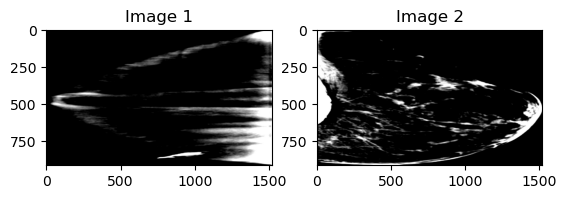

In [20]:
import matplotlib.pyplot as plt
indx=15
# Plot the first image
plt.subplot(1, 2, 1)
plt.imshow(batch['images'][indx][1].resenumpy().transpose(1, 2, 0))
plt.title('Image 1')

# Plot the second image
plt.subplot(1, 2, 2)
plt.imshow(batch['images'][indx][0].numpy().transpose(1, 2, 0))
plt.title('Image 2')

# Display the plot
plt.show()

In [ ]:
def __loadimagepair(item):
    if item['Missing']=='R':
        imageL = Image.open(item['processed_filepath_L']).convert('RGB')
        imageR = imageL.transpose(method=Image.Transpose.FLIP_LEFT_RIGHT)
    elif item['Missing'] == 'L':
        imageR = Image.open(item['processed_filepath_R']).convert('RGB').transpose(method=Image.Transpose.FLIP_LEFT_RIGHT)
        imageL = imageR.transpose(method=Image.Transpose.FLIP_LEFT_RIGHT)
    else :
        imageL = Image.open(item['processed_filepath_L']).convert('RGB')
        imageR = Image.open(item['processed_filepath_R']).convert('RGB').transpose(method=Image.Transpose.FLIP_LEFT_RIGHT)
    print(item)
    return imageL,imageR
item = df[df.Laterality != 'Both'].sample(5).iloc[0]
images = __loadimagepair(item)
images[1].resize((912,1520)).show(),images[0].resize((912,1520)).show()

## Model

In [17]:
model = build_multiview_model(
    ckpt=ckpt,
    tokenizer=tokenizer,
    args=args,
)


{'source': 'cnn', 'name': 'tf_efficientnet_b5_ns-detect', 'pretrained': True, 'model_type': 'cnn'}
<All keys matched successfully>
Loaded pretrained weights for efficientnet-b5


In [12]:
batch['text_tokens']['input_ids'].shape

torch.Size([8, 256])

In [7]:
batch['images'].to(args.device)
output = model(batch,device = args.device)

and text embed  torch.Size([4, 512])
Text feat and text normalize shapes torch.Size([4, 768]) torch.Size([4, 512])


In [13]:
batch.keys()

dict_keys(['images', 'acc', 'labels', 'text_tokens', 'view_seqs'])

In [ ]:

# # Load the model
# model = BreastClipMIRAITransformer(args, ckpt)

# # Move the model to the device
# model.to(args.device)

# # Define a single batch of data
# batch_size = 1
# num_images = 2
# image_size = (224, 224)
# num_channels = 3

# # Create a random batch of images
# images = torch.randn(batch_size, num_images, num_channels, image_size[0], image_size[1])

# # Create a batch of view labels
# view_labels = torch.tensor([[0, 1]])  # 0: R-MLO, 1: L-MLO
images, view_labels = batch['images'] , batch['view_seqs']
# Move the data to the args.device
images = images.to(args.device)
view_labels = view_labels.to(args.device)

# Perform inference
embeddings = model(images, view_labels)

# Print the output
print(embeddings.shape)

In [ ]:
model

## Model Finetuning

In [18]:
available_memory = torch.cuda.get_device_properties(args.device).total_memory
print(f"Available GPU memory: {available_memory / (1024 * 1024 * 1024):.2f} GB")
# Clear GPU memory
torch.cuda.empty_cache()
# Optionally, you can also reset the PyTorch CUDA cache
torch.cuda.reset_max_memory_cached()

Available GPU memory: 39.38 GB


/home/ixb004/miniconda3/envs/mammoalbef/lib/python3.9/site-packages/torch/cuda/memory.py:391: FutureWarning: torch.cuda.reset_max_memory_cached now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(


In [33]:
os.makedirs(f"checkpoints/exp{config['experiment']}", exist_ok=True)
os.makedirs(f"results/exp{config['experiment']}", exist_ok=True)

In [35]:
len(dataloader.dataset)

70328

In [5]:
with open("finetune-config.yaml", "r") as f:
    config = yaml.safe_load(f)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config['device'] = device
with init_empty_weights():
    # my_model = ModelClass(...)
    model, tokenizer = load_model(config)
dataloader = load_dataloader(config,tokenizer=tokenizer)
other = torch.load('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/Mammo-CLIP/src/codebase/finetune/checkpoints/exp0/exp0_final.pth',map_location='cpu')
model.load_state_dict(other['model'], assign=True)


/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/Mammo-CLIP/src/codebase/finetune/model_utils.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(c

{'source': 'cnn', 'name': 'tf_efficientnet_b5_ns-detect', 'pretrained': True, 'model_type': 'cnn'}
<All keys matched successfully>
Loaded pretrained weights for efficientnet-b5


/tmp/ipykernel_839158/528338811.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  other = torch.load('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/Mammo-CLIP/sr

<All keys matched successfully>

In [51]:
from accelerate import Accelerator

accelerator = Accelerator()
unwrapped_model = accelerator.unwrap_model(newmodel)

In [4]:
for k, v in batch.items():
    if isinstance(v, torch.Tensor) :
        print(k)

images
view_seqs


In [19]:
dataloader.dataset.ann.sample(frac=0.1, random_state=42).shape
dataloader.dataset.ann.shape

(72328, 13)

In [3]:
batch  =next(iter(dataloader))

print(batch.keys(), len(batch['acc']))

dict_keys(['images', 'acc', 'labels', 'text_tokens', 'view_seqs']) 4


In [3]:
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import torch.nn as nn
model.to(args.device)
def get_memory_usage():
    mem_usage = torch.cuda.memory_allocated() / (1024 * 1024)  # in MB
    return mem_usage
def contrastive_loss(image_embeddings, text_embeddings, logit_scale):
    logits_per_image = logit_scale * image_embeddings @ text_embeddings.T
    logits_per_text = logits_per_image.T
    labels = torch.arange(logits_per_image.shape[0], device=logits_per_image.device)

    loss_img = nn.CrossEntropyLoss()(logits_per_image, labels)
    loss_txt = nn.CrossEntropyLoss()(logits_per_text, labels)
    return (loss_img + loss_txt) / 2
epochs = 1
optimizer = AdamW(model.image_model.parameters(), lr=float(config["learning_rate"]), weight_decay=config["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
model.train()

loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for batch in progress_bar:
        optimizer.zero_grad()
        # # Need to change to handle view
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        batch["text_tokens"] = batch["text_tokens"].to(device)

        output = model(batch,args.device)
        loss = contrastive_loss(output["image_embeddings"], output["text_embeddings"], output["logit_scale"])
        loss.backward()
        optimizer.step()
        scheduler.step()
        mem_usage = get_memory_usage()
        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item(), mem=f"{mem_usage} MB")

Epoch 1/1:   0%|          | 0/72328 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
logits_per_image,logits_per_text,loss_img,labels

(tensor([[-0.9212]], device='cuda:0', grad_fn=<MmBackward0>),
 tensor([[-0.9212]], device='cuda:0', grad_fn=<PermuteBackward0>),
 tensor(0., device='cuda:0', grad_fn=<NllLossBackward0>),
 tensor([0], device='cuda:0'))

In [8]:
output["image_embeddings"].shape, output["text_embeddings"].shape
logits_per_image = output["logit_scale"] * output["image_embeddings"] @ output["text_embeddings"].T
logits_per_text = logits_per_image.T
labels = torch.arange(logits_per_image.shape[0], device=logits_per_image.device)

loss_img = nn.CrossEntropyLoss()(logits_per_image, labels)
loss_txt = nn.CrossEntropyLoss()(logits_per_text, labels)

## Embeddings

In [61]:
with h5py.File("/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/embeddings/img_feats_g20_mammo_ML256.hdf5", "r") as f:
    fkeys = f.keys()
    loaded_image_embeddings = f["txt_features"][:]
    loaded_text_embeddings = f["features"][:]
loaded_image_embeddings.shape
loaded_text_embeddings.shape

(72328, 512)

| Metric (ml-256) | Mammoclip Rare (n=12330) | Mammoclip Freq (n=59998) | Mammoclip All (n=72328) | ALBEF Rare (n=12330) | ALBEF Freq (n=59998) | ALBEF All (n=72328) | MII Rare (n=12330) | MII Freq (n=59998) | MII All (n=72328) |
|----------------|---------------------------|-------------------------|------------------------|---------------------|---------------------|-------------------|-------------------|-------------------|------------------|
| I2T Recall@1 | 0.0109 [0.0090, 0.0127] | 0.0491 [0.0474, 0.0508] | 0.0426 [0.0411, 0.0441] | 0.1261 [0.1203, 0.1320] | **0.4337** [0.4298, 0.4377] | 0.3813 [0.3778, 0.3848] | 0.0024 [0.0016, 0.0033] | 0.1643 [0.1614, 0.1673] | 0.1367 [0.1342, 0.1392] |
| I2T Recall@5 | 0.0314 [0.0283, 0.0345] | 0.1270 [0.1243, 0.1297] | 0.1107 [0.1084, 0.1130] | 0.2045 [0.1973, 0.2116] | **0.5784** [0.5745, 0.5824] | 0.5147 [0.5110, 0.5183] | 0.0155 [0.0133, 0.0177] | 0.5005 [0.4965, 0.5045] | 0.4178 [0.4142, 0.4214] |
| I2T Recall@10 | 0.0474 [0.0437, 0.0512] | 0.1600 [0.1570, 0.1629] | 0.1408 [0.1383, 0.1433] | 0.2427 [0.2352, 0.2503] | 0.6241 [0.6203, 0.6280] | 0.5591 [0.5555, 0.5627] | 0.0312 [0.0282, 0.0343] | **0.6666** [0.6628, 0.6704] | 0.5583 [0.5547, 0.5619] |
| T2I Recall@1 | 0.0077 [0.0062, 0.0092] | 0.0346 [0.0331, 0.0360] | 0.0300 [0.0287, 0.0312] | 0.1356 [0.1296, 0.1416] | **0.6574** [0.6536, 0.6612] | 0.5685 [0.5649, 0.5721] | 0.0024 [0.0015, 0.0032] | 0.1028 [0.1004, 0.1053] | 0.0857 [0.0837, 0.0877] |
| T2I Recall@5 | 0.0377 [0.0343, 0.0411] | 0.6043 [0.6004, 0.6082] | 0.5077 [0.5041, 0.5114] | 0.3457 [0.3373, 0.3541] | **0.8693** [0.8666, 0.8720] | 0.7801 [0.7771, 0.7831] | 0.0115 [0.0096, 0.0134] | 0.4379 [0.4339, 0.4418] | 0.3652 [0.3617, 0.3687] |
| T2I Recall@10 | 0.0956 [0.0904, 0.1008] | 0.7789 [0.7756, 0.7822] | 0.6624 [0.6590, 0.6658] | 0.4547 [0.4460, 0.4635] | **0.9424** [0.9406, 0.9443] | 0.8593 [0.8568, 0.8618] | 0.0229 [0.0202, 0.0255] | 0.6534 [0.6496, 0.6572] | 0.5459 [0.5423, 0.5496] |

In [4]:
import h5py
import time


start = time.time()

df1 = pd.read_csv('/mnt/PURENFS/SalkowskiPreprocessedBreast/MedImageInsightEmbeddings.csv', 
                    delimiter=',', 
                    engine='python', 
                    names=['image_name', 'len_image_features', 'len_text_features', 'image_features', 'text_features'], 
                    header=0)
 
try:
    df2 = pd.read_csv("/mnt/PURENFS/SalkowskiPreprocessedBreast/data/findings_new_birads_jg_dbt.csv", encoding='utf-8')
except UnicodeDecodeError:
    df2 = pd.read_csv("/mnt/PURENFS/SalkowskiPreprocessedBreast/data/findings_new_birads_jg_dbt.csv", encoding='latin1')  # Use a fallback encoding
inter = time.time()-start
df1['image_name'] = df1['image_name'].astype(str)
df1['image_name'] = df1['image_name'].fillna('').astype(str)
 
df1['AccessionNumber'] = df1['image_name'].str.extract(r'^(.*?)_')[0]
df1['image_id'] = df1.image_name.apply(lambda x : x.split('.')[0])
test = pd.read_json('/mnt/PURENFS/SalkowskiPreprocessedBreast/code/ALBEF/data/uw_madison_test_with_groupids.json')
df1 = df1[df1['image_id'].isin(test.image_id)]
# Merge DataFrames on AccessionNumber
merged_df = pd.merge(df1, df2, left_on='AccessionNumber', right_on='Accession Number', how='inner')
start = time.time()
# Parse the 'image_features' column into numerical arrays
merged_df['text_features'] = merged_df['text_features'].apply(lambda x: np.array([float(i) for i in x.split(',')]))
merged_df['image_features'] = merged_df['image_features'].apply(lambda x: np.array([float(i) for i in x.split(',')]))
 
# Stack the embeddings into a 2D array
image_embeds = np.vstack(merged_df['image_features'].values)

# Stack the embeddings into a 2D array
embeddings = np.vstack(merged_df['text_features'].values)


print("total time to write", time.time()-start)
image_embeds.shape ,embeddings.shape

start = time.time()
with h5py.File("/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/embeddings/img_feats_g20_MedImageInsight.h5", "w") as f:
    f.create_dataset("image_embeddings", data=image_embeds)
    f.create_dataset("text_embeddings", data=embeddings)
print("total time to write", time.time()-start)
start = time.time()
with h5py.File("/mnt/PURENFS/SalkowskiPreprocessedBreast/code/MammoCLIP/embeddings/img_feats_g20_MedImageInsight.h5", "r") as f:
    fkeys = f.keys()
    loaded_image_embeddings = f["image_embeddings"][:]
    loaded_text_embeddings = f["text_embeddings"][:]

print("total time to load  : ", time.time()- start)
print(loaded_image_embeddings.shape, loaded_text_embeddings.shape)